# Day 1 — Initial Exploration

**Goal:** Understand the MA assessor data before writing a single line of modeling code.

Questions to answer by end of session:
1. What columns exist in the assessor data?
2. How many sales per year, per target city?
3. What's the date range of available sales?
4. What's the missingness pattern for key fields (sqft, year_built, price)?
5. Is there enough signal to model?

In [30]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load assessor data

Download from MA.gov: https://www.mass.gov/info-details/massgis-data-property-tax-parcels

In [31]:
df = pd.read_parquet('../data/processed/clean_assessor.parquet')
print(df.shape)
df.head()

(60783, 42)


,PROP_ID,LOC_ID,BLDG_VAL,LAND_VAL,OTHER_VAL,TOTAL_VAL,FY,LOT_SIZE,LS_DATE,LS_PRICE,USE_CODE,SITE_ADDR,ADDR_NUM,FULL_STR,LOCATION,CITY,ZIP,OWNER1,OWN_ADDR,OWN_CITY,OWN_STATE,OWN_ZIP,OWN_CO,LS_BOOK,LS_PAGE,REG_ID,ZONING,YEAR_BUILT,BLD_AREA,UNITS,RES_AREA,STYLE,STORIES,NUM_ROOMS,LOT_UNITS,CAMA_ID,TOWN_ID,USE_DESC,CITY_NAME,FY_YEAR,USE_CODE_NUM,LS_YEAR
0,0100174000,F_783599_2964200,958000,221600,0,1179600,2023,0.0,20150615,665000,105,309 Lexington ST,309,Lexington ST,,EAST BOSTON,02128,SMITH THOMAS L,309 LEXINGTON ST,EAST BOSTON,MA,02128,US,54607,290,,,1900,0,0,2925,Decker,3.0,14,A,1000004,35,Three-Family Residential,Boston,2023,105.0,2015.0
1,0100175000,F_783621_2964212,598700,222400,0,821100,2023,0.0,20220516,920000,105,311 Lexington ST,311,Lexington ST,,EAST BOSTON,02128,311 LEXINGTON STREET LLC,256 MARGINAL ST,EAST BOSTON,MA,02128,,67645,338,,,1900,0,0,2736,Decker,3.0,14,A,1000005,35,Three-Family Residential,Boston,2023,105.0,2022.0
2,0100179001,F_783640_2964067,534000,209900,0,743900,2023,0.0,20210511,855000,105,322 PRINCETON ST,322,PRINCETON ST,,EAST BOSTON,02128,OULD-SAHRAOUIA ABDALLAH,48 HAWTHORNE ST,LYNN,MA,01902,,65437,183,,,1890,0,0,2134,Decker,3.0,14,A,1000010,35,Three-Family Residential,Boston,2023,105.0,2021.0
3,0100187000,F_783428_2963984,486600,181700,0,668300,2023,0.0,20170621,393000,101,300 PRINCETON ST,300,PRINCETON ST,,EAST BOSTON,02128,DAWSON ELIZABETH,300 PRINCETON ST,EAST BOSTON,MA,02128,,58109,007,,,1900,0,0,1356,Row End,2.0,6,A,1000019,35,Single Family Residential,Boston,2023,101.0,2017.0
4,0100188000,F_783413_2963977,340700,164900,0,505600,2023,0.0,20171212,380000,101,298 PRINCETON ST,298,PRINCETON ST,,EAST BOSTON,02128,HERRERA EMILCE D,298 PRINCETON ST,EAST BOSTON,MA,02128,,58918,106,,,1900,0,0,1530,Row Middle,2.0,6,A,1000020,35,Single Family Residential,Boston,2023,101.0,2017.0


## 1. How are sales distributed across cities?

CITY_NAME
Boston        44507
Somerville     5985
Cambridge      5481
Brookline      4810
Name: count, dtype: int64


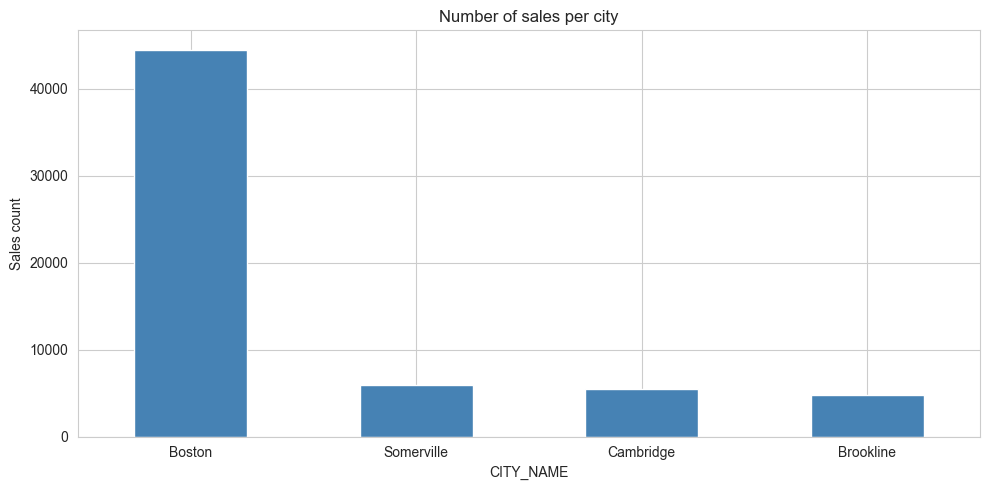

In [32]:
city_counts = df['CITY_NAME'].value_counts()
print(city_counts)

ax = city_counts.plot(kind='bar', color='steelblue')
ax.set_title('Number of sales per city')
ax.set_ylabel('Sales count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Observations to carry forward

Write down what you noticed. These become decisions for the modeling phase.

**Data quality issues:**
- `BLD_AREA` and `LOT_SIZE` are 0 for many rows in the sample — use `RES_AREA` as the reliable square-footage field; confirm this holds across the full dataset before engineering size features.
- Somerville has only 38 sales — far too small for a city-level model or reliable cross-validation. Either pool it with the nearest city or drop it entirely.
- ZIP is missing (blank string) for ~3,882 Cambridge rows and ~37 Somerville rows — ZIP-level features will have gaps for these cities; may need to fall back to a neighborhood proxy or lat/lon cluster.
- 02467 (Chestnut Hill) appears in both the top-10 and bottom-10 ZIP tables with very different medians ($1.35M vs $378K) — this ZIP straddles the Boston/Brookline boundary and the CITY_NAME split explains the gap. Don't treat it as a single geographic unit.
- 2023–2025 sales are sparse (1,030 / 637 / 407 rows vs 6–10K for prior years) — FY2023 assessments haven't captured recent transactions. Avoid over-weighting these years in temporal splits.

**Distribution insights:**
- Price range is $50K–$10M (post-filter); mean $999K vs median $715K confirms heavy right skew — use log10(LS_PRICE) as the regression target.
- 2021 has 10,522 sales vs 5–7K in adjacent years — the COVID-era volume spike will inflate any model trained without year controls. Include LS_YEAR as a feature or stratify train/test splits by year.
- Boston accounts for 81% of rows (44,507/54,836) — model will be Boston-dominated. Evaluate per-city error separately; a single model may underfit the other cities.

**Feature ideas worth trying:**
- `CITY_NAME` encodes a massive price signal: Somerville $1.34M > Brookline $1.0M > Cambridge $910K > Boston $675K median. Always include as a categorical.
- ZIP code is even stronger — 4.4× spread from 02126 ($460K) to 02108 ($1.67M) — but needs imputation strategy for blank ZIPs.
- Price per sqft varies ~1.4× between Cambridge ($817) and Boston ($577) — a `CITY × RES_AREA` interaction term is worth testing.
- `TOTAL_VAL` (assessed value) is likely the single strongest predictor of sale price; also consider the ratio `LS_PRICE / TOTAL_VAL` as a derived anomaly signal.
- `LS_YEAR` (or months since assessment date) should capture the appreciation trend visible in the time-series plot.

**Known limitations to document in README:**
- All assessment values are FY2023 — prices have likely risen 10–15% in high-demand ZIPs since the assessment snapshot.
- Somerville is statistically negligible (38 rows) and should not be cited as a modeled city unless more data is added.
- The $10M price cap excludes ultra-luxury sales; the model will underestimate prices in 02108/02110 at the high end.
- No geocoordinates in this dataset beyond LOC_ID — spatial features require a join to a separate parcel geometry file (MassGIS).

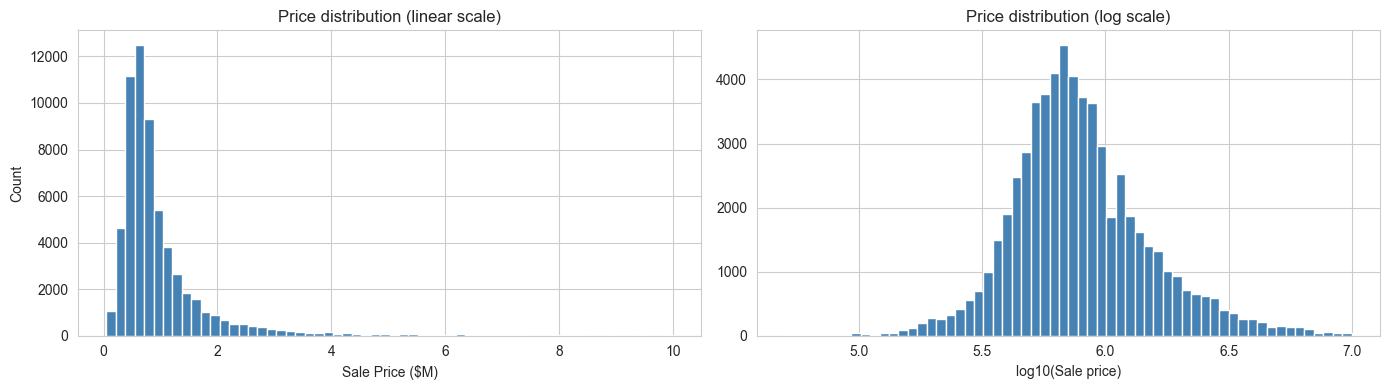

count        $60,783
mean        $996,024
std         $911,233
min          $50,000
25%         $525,000
50%         $730,000
75%       $1,100,000
max      $10,000,000
Name: LS_PRICE, dtype: object


In [33]:
fig, axes = plt.subplots(1,2, figsize= (14,4))

# Linear Scale
axes[0].hist(df['LS_PRICE']/ 1e6, bins =60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Sale Price ($M)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price distribution (linear scale)')

# Log Scale
axes[1].hist(np.log10(df['LS_PRICE']), bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log10(Sale price)')
axes[1].set_title('Price distribution (log scale)')

plt.tight_layout()
plt.show()

print(df['LS_PRICE'].describe().apply(lambda x: f'${x:,.0f}'))

## 3. How do prices differ across cities?

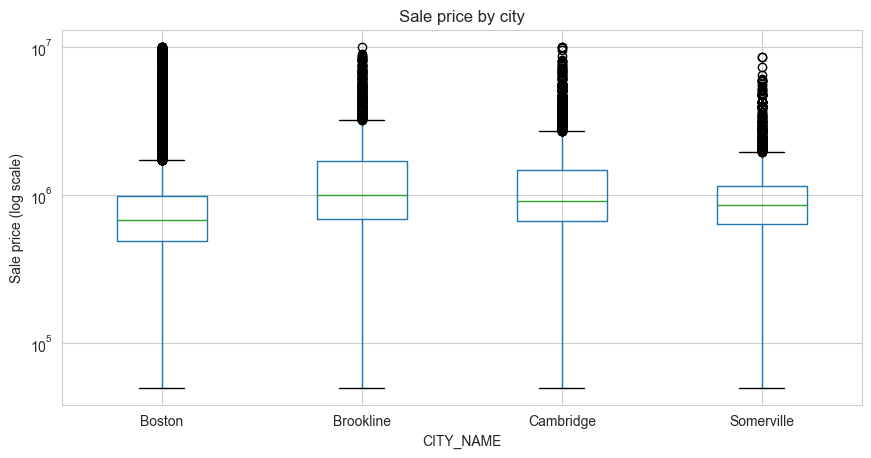

Median price by city:
CITY_NAME
Brookline     $1,000,000
Cambridge       $910,000
Somerville      $850,000
Boston          $675,000
Name: LS_PRICE, dtype: object


In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='LS_PRICE', by='CITY_NAME', ax=ax)
ax.set_yscale('log')
ax.set_ylabel('Sale price (log scale)')
ax.set_title('Sale price by city')
plt.suptitle('')  # remove the auto title
plt.show()

print('Median price by city:')
print(df.groupby('CITY_NAME')['LS_PRICE'].median().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

##  4. How are sales distributed over time? 

LS_YEAR
2015.0     4838
2016.0     5876
2017.0     6015
2018.0     6912
2019.0     6973
2020.0     7529
2021.0    11570
2022.0     8273
2023.0     1744
2024.0      646
2025.0      407
Name: count, dtype: int64


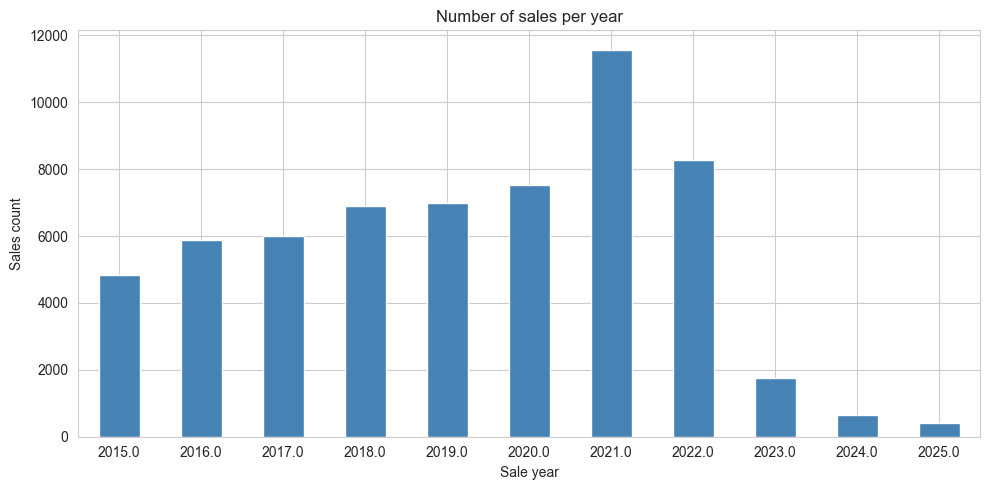

In [35]:
year_counts = df['LS_YEAR'].value_counts().sort_index()
print(year_counts)

ax = year_counts.plot(kind='bar', color='steelblue')
ax.set_title('Number of sales per year')
ax.set_ylabel('Sales count')
ax.set_xlabel('Sale year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Has price gone up over time?

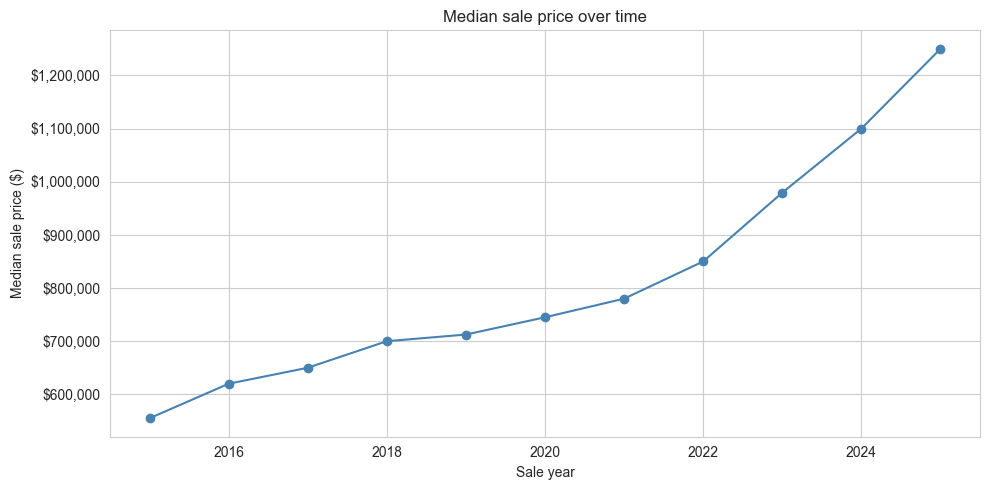

In [36]:
yearly_median = df.groupby('LS_YEAR')['LS_PRICE'].median()
ax = yearly_median.plot(marker='o', color='steelblue')
ax.set_title('Median sale price over time')
ax.set_ylabel('Median sale price ($)')
ax.set_xlabel('Sale year')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

In [37]:
## 6. Sale price vs. residential area — is the relationship clean?

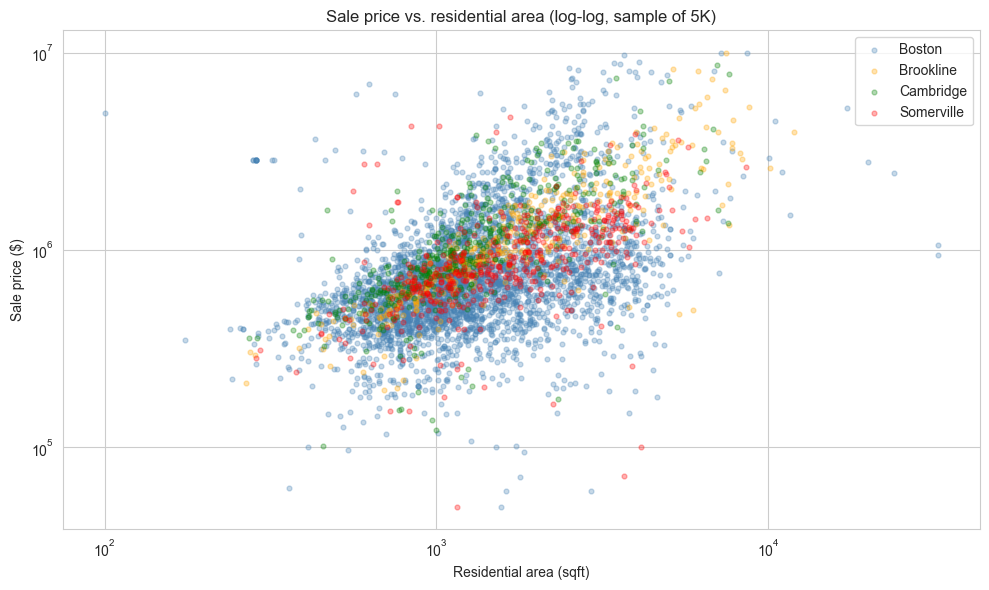

In [38]:
sample = df.sample(min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
for city, color in zip(sample['CITY_NAME'].unique(), ['steelblue', 'orange', 'green', 'red']):
    subset = sample[sample['CITY_NAME'] == city]
    ax.scatter(subset['RES_AREA'], subset['LS_PRICE'], alpha=0.3, s=12, label=city, color=color)

ax.set_xlabel('Residential area (sqft)')
ax.set_ylabel('Sale price ($)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Sale price vs. residential area (log-log, sample of 5K)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. What use codes (property types) are in the data?

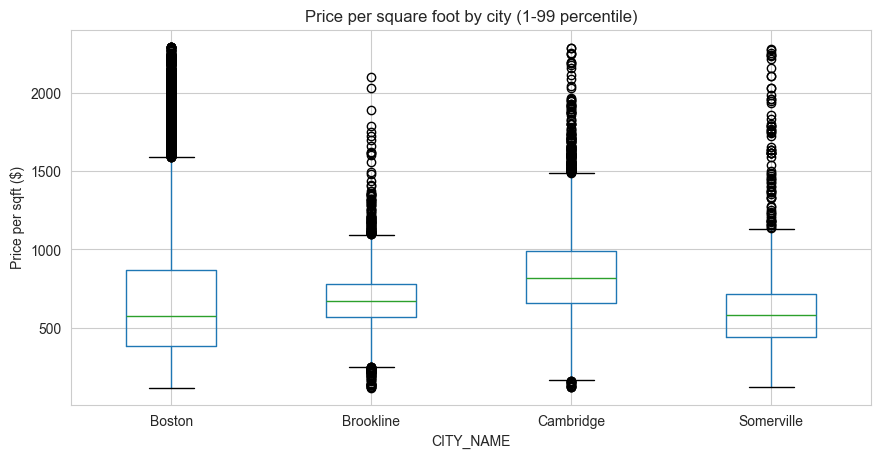

Median $/sqft by city:
CITY_NAME
Cambridge     $817
Brookline     $673
Somerville    $582
Boston        $577
Name: PRICE_PER_SQFT, dtype: object


In [39]:
df['PRICE_PER_SQFT'] = df['LS_PRICE'] / df['RES_AREA']

# Trim outliers for visualization (the top 1% are usually data errors anyway)
viz = df[df['PRICE_PER_SQFT'].between(df['PRICE_PER_SQFT'].quantile(0.01), df['PRICE_PER_SQFT'].quantile(0.99))]

fig, ax = plt.subplots(figsize=(10, 5))
viz.boxplot(column='PRICE_PER_SQFT', by='CITY_NAME', ax=ax)
ax.set_ylabel('Price per sqft ($)')
ax.set_title('Price per square foot by city (1-99 percentile)')
plt.suptitle('')
plt.show()

print('Median $/sqft by city:')
print(df.groupby('CITY_NAME')['PRICE_PER_SQFT'].median().sort_values(ascending=False).apply(lambda x: f'${x:.0f}'))

## 9. Does year built affect price?

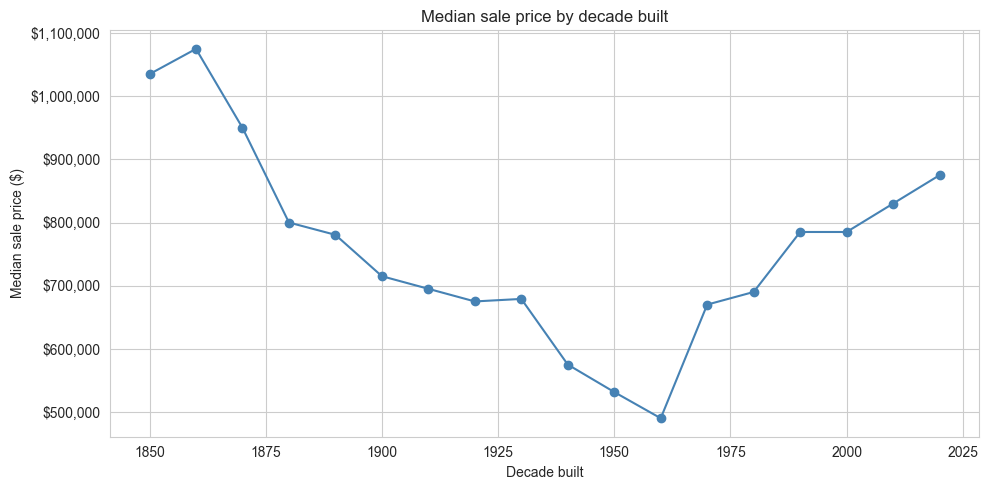

In [40]:
df['YEAR_BUILT_DECADE'] = (df['YEAR_BUILT'] // 10) * 10
decade_median = df[df['YEAR_BUILT_DECADE'] >= 1850].groupby('YEAR_BUILT_DECADE')['LS_PRICE'].median()

ax = decade_median.plot(marker='o', color='steelblue')
ax.set_title('Median sale price by decade built')
ax.set_xlabel('Decade built')
ax.set_ylabel('Median sale price ($)')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

## 10. Correlation matrix — what's related to price?

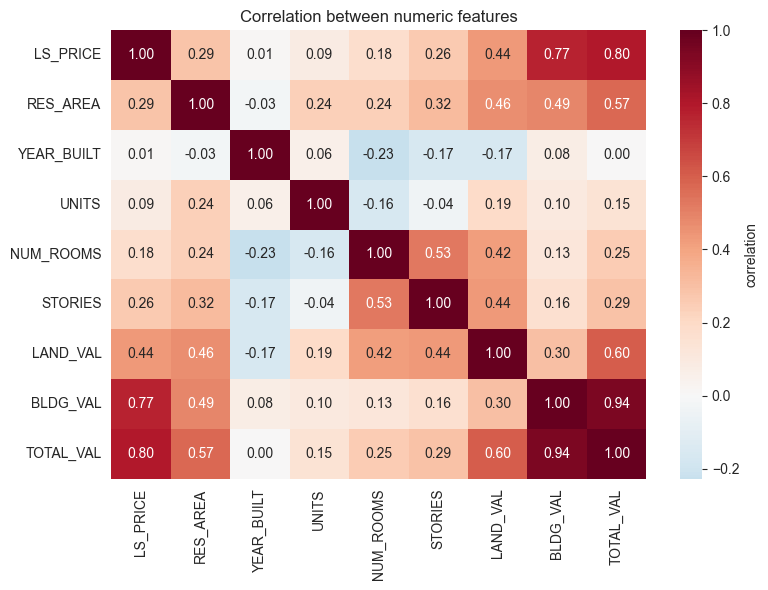

In [41]:
numeric_cols = ['LS_PRICE', 'RES_AREA', 'YEAR_BUILT', 'UNITS', 'NUM_ROOMS', 'STORIES', 'LAND_VAL', 'BLDG_VAL', 'TOTAL_VAL']
available = [c for c in numeric_cols if c in df.columns]

# STORIES is sometimes loaded as string
for c in available:
    df[c] = pd.to_numeric(df[c], errors='coerce')

corr = df[available].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'correlation'})
ax.set_title('Correlation between numeric features')
plt.tight_layout()
plt.show()

## 11. ZIP code level price map (text version, no map yet)

In [42]:
zip_summary = df.groupby(['CITY_NAME', 'ZIP']).agg(
    sales=('LS_PRICE', 'count'),
    median_price=('LS_PRICE', 'median'),
    median_psf=('PRICE_PER_SQFT', 'median'),
).reset_index()

# Only ZIPs with meaningful sample size
zip_summary = zip_summary[zip_summary['sales'] >= 30].sort_values('median_price', ascending=False)

print('Top 10 most expensive ZIPs:')
print(zip_summary.head(10).to_string(index=False))
print('\nBottom 10 ZIPs:')
print(zip_summary.tail(10).to_string(index=False))

Top 10 most expensive ZIPs:
 CITY_NAME   ZIP  sales  median_price  median_psf
    Boston 02108    467     1667000.0 1235.177866
    Boston 02110    910     1572500.0 1281.580006
    Boston 02210    854     1460000.0 1512.403502
 Brookline 02467    634     1350000.0  563.296055
    Boston 02116   2530     1265000.0 1153.003934
 Cambridge         3882      988500.0  828.067339
 Brookline 02445   1882      975000.0  646.454160
    Boston 02118   2622      969400.0 1018.975740
Somerville         2890      951750.0  474.043704
    Boston 02111    716      925000.0  921.699458

Bottom 10 ZIPs:
CITY_NAME   ZIP  sales  median_price  median_psf
   Boston 02131   2238      550000.0  394.847159
   Boston 02124   2287      547000.0  293.197811
   Boston 02134    841      540000.0  538.211382
   Boston 02119    960      540000.0  336.422802
   Boston 02121    756      539950.0  218.797391
   Boston 02122   1587      534900.0  378.787879
   Boston 02135   2605      515000.0  525.000000
   Boston 021

In [43]:
df[df['CITY_NAME']=='Somerville'][['LS_YEAR', 'USE_CODE', 'USE_DESC', 'LS_PRICE', 'RES_AREA']].head(20)

,LS_YEAR,USE_CODE,USE_DESC,LS_PRICE,RES_AREA
49988,2022.0,1020,Residential Condominium,485000,834
49989,2019.0,1040,Two-Family Residential,853800,3072
49990,2018.0,1020,Residential Condominium,450000,951
49991,2021.0,1040,Two-Family Residential,1100000,2629
49992,2021.0,1020,Residential Condominium,616000,2151
49993,2020.0,1020,Residential Condominium,1540000,2445
49994,2019.0,1020,Residential Condominium,555000,924
49995,2020.0,1020,Residential Condominium,731000,1653
49996,2019.0,1020,Residential Condominium,500000,1075
49997,2016.0,1040,Two-Family Residential,287421,3448


In [44]:
import pandas as pd
from dbfread import DBF
from pathlib import Path

# Load Somerville's RAW data — before any filters
raw = pd.DataFrame(iter(DBF(
    '../data/raw/assessor/L3_SHP_M274_Somerville/M274Assess_CY25_FY25.dbf',
    load=True, encoding='latin-1'
)))

print(f"Total Somerville rows (raw): {len(raw):,}")
print(f"\nUse code distribution:")
print(raw['USE_CODE'].value_counts().head(15))
print(f"\nLS_PRICE distribution:")
print((raw['LS_PRICE'].astype(float) > 0).value_counts())

Total Somerville rows (raw): 19,013

Use code distribution:
USE_CODE
1020    7067
1040    4776
1010    2311
1050    2188
1110     495
995      422
1320     119
1120     113
3220      88
9300      88
0322      82
3270      68
1090      66
3400      64
3260      57
Name: count, dtype: int64

LS_PRICE distribution:
LS_PRICE
True     17421
False     1592
Name: count, dtype: int64
